/var/folders/gn/9s3465fs47zbr19dkkb4dxwh0000gn/T/ipykernel_49965/829347997.py:107: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 0.83, 0.95]) # Ajustado el rect


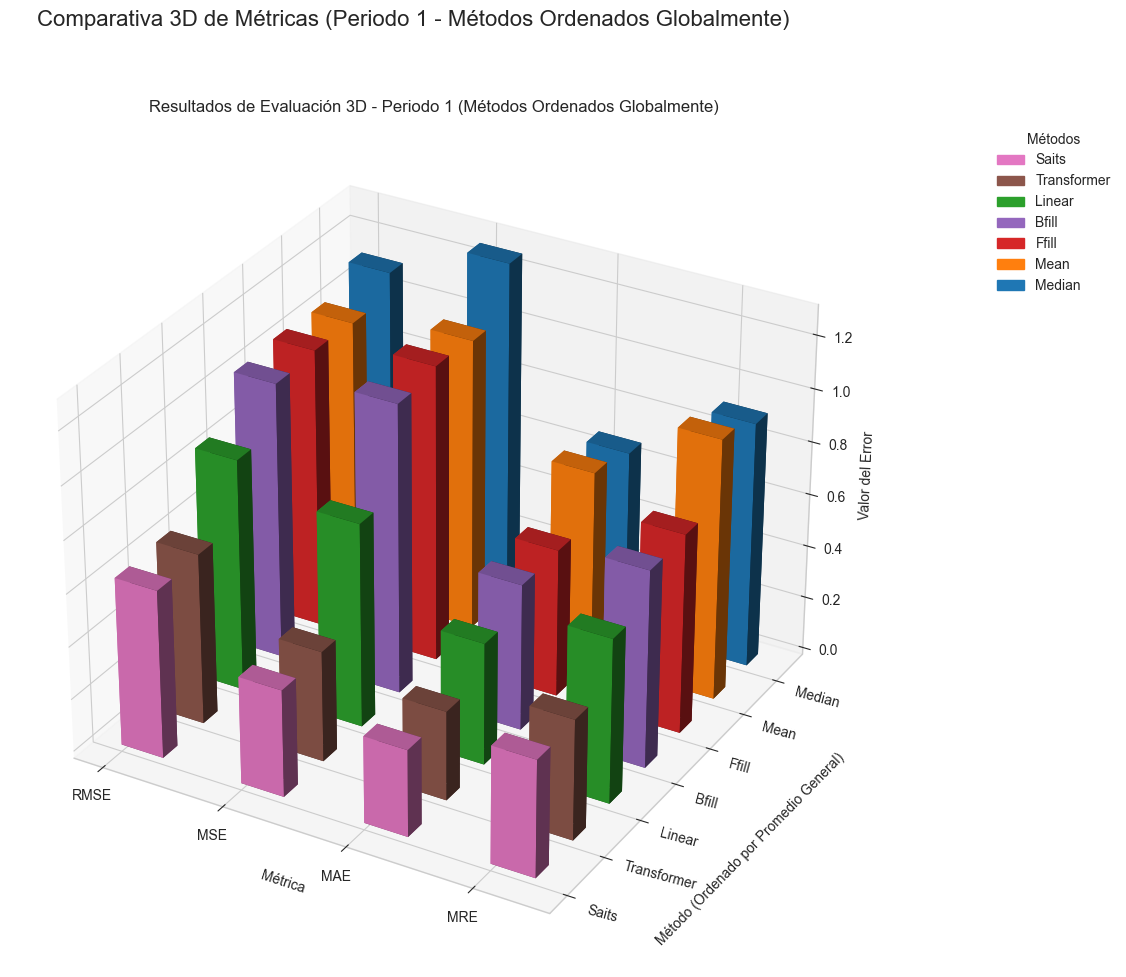

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd

# Datos de la tabla para el Periodo 1
data_periodo1 = {
    'Metrica': ['RMSE', 'MSE', 'MAE', 'MRE'],
    'Median': [1.1342, 1.2865, 0.6910, 0.9311],
    'Mean': [1.0521, 1.1069, 0.7346, 0.9898],
    'Linear': [0.8796, 0.7737, 0.4621, 0.6226],
    'Ffill': [1.0604, 1.1244, 0.5618, 0.7569],
    'Bfill': [1.0487, 1.0997, 0.5554, 0.7484],
    'Transformer': [0.6471, 0.4187, 0.3378, 0.4552],
    'Saits': [0.6370, 0.4057, 0.3291, 0.4434]
}
df_raw_periodo1 = pd.DataFrame(data_periodo1)

# --- Ordenar el DataFrame por el rendimiento promedio de los métodos (por ejemplo) ---
# Primero, necesitamos pivotar la tabla para tener métodos como índice y métricas como columnas
df_pivot = df_raw_periodo1.set_index('Metrica').transpose() # Ahora los métodos son filas

# Calcular el promedio de error para cada método
df_pivot['PromedioError'] = df_pivot.mean(axis=1)

# Ordenar los métodos por este promedio (de menor a mayor error promedio)
df_sorted_methods = df_pivot.sort_values(by='PromedioError', ascending=True)

# Volver a la estructura original (métricas como índice, métodos ordenados como columnas)
# y quitar la columna auxiliar 'PromedioError'
df_periodo1_sorted_for_3d = df_sorted_methods.drop(columns=['PromedioError']).transpose()
# Ahora las columnas de df_periodo1_sorted_for_3d están ordenadas por el rendimiento promedio del método


# Colores para los métodos (usaremos un diccionario para mantener la consistencia)
method_color_map = {
    'Median': '#1f77b4',
    'Mean': '#ff7f0e',
    'Linear': '#2ca02c',
    'Ffill': '#d62728',
    'Bfill': '#9467bd',
    'Transformer': '#8c564b',
    'Saits': '#e377c2'
}


# --- Función para crear el gráfico de barras 3D (modificada para usar el df ordenado) ---
def plot_3d_metrics_comparison_globally_sorted(df_input, title, ax, color_map_dict):
    # El DataFrame df_input ya tiene las columnas (métodos) en el orden deseado
    metrics = df_input.index.tolist() # Métricas ahora son el índice
    methods_sorted = df_input.columns.tolist() # Métodos (columnas) ya están ordenados

    n_metrics = len(metrics)
    n_methods = len(methods_sorted)

    x_pos = np.arange(n_metrics) # Posiciones para las métricas en el eje X
    y_pos = np.arange(n_methods) # Posiciones para los métodos ordenados en el eje Y

    x_mesh, y_mesh = np.meshgrid(x_pos, y_pos)
    x_mesh = x_mesh.flatten()
    y_mesh = y_mesh.flatten()

    z_values = []
    bar_colors = []

    # Iterar en el orden de los métodos ya clasificados en el DataFrame
    for method_idx, method_name in enumerate(methods_sorted):
        for metric_idx, metric_name in enumerate(metrics):
            value = df_input.loc[metric_name, method_name]
            z_values.append(value)
            bar_colors.append(color_map_dict[method_name]) # Usar el color mapeado

    z_values = np.array(z_values)
    dx = dy = 0.35
    dz = z_values

    ax.bar3d(x_mesh, y_mesh, np.zeros_like(dz), dx, dy, dz, color=bar_colors, shade=True)

    ax.set_title(title)
    ax.set_xlabel('Métrica')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(metrics)

    ax.set_ylabel('Método (Ordenado por Promedio General)', labelpad=25)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(methods_sorted, va='center', ha='left', rotation=-15)

    ax.set_zlabel('Valor del Error')

    # Leyenda (ya que los métodos están en un orden fijo ahora)
    handles = [plt.Rectangle((0,0),1,1, color=color_map_dict[method]) for method in methods_sorted]
    ax.legend(handles, methods_sorted, title='Métodos', bbox_to_anchor=(1.15, 1), loc='upper left')


# --- Crear la figura 3D ---
fig = plt.figure(figsize=(16, 11)) # Ajustado el tamaño
plt.style.use('seaborn-v0_8-whitegrid')

ax1 = fig.add_subplot(111, projection='3d')
plot_3d_metrics_comparison_globally_sorted(
    df_periodo1_sorted_for_3d, # Usamos el DataFrame con métodos ordenados
    'Resultados de Evaluación 3D - Periodo 1 (Métodos Ordenados Globalmente)',
    ax1,
    method_color_map
)

plt.tight_layout(rect=[0, 0, 0.83, 0.95]) # Ajustado el rect
plt.suptitle('Comparativa 3D de Métricas (Periodo 1 - Métodos Ordenados Globalmente)', fontsize=16, y=0.98)
plt.show()

/var/folders/gn/9s3465fs47zbr19dkkb4dxwh0000gn/T/ipykernel_49965/914984364.py:108: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 0.83, 0.95]) # Ajustado el rect


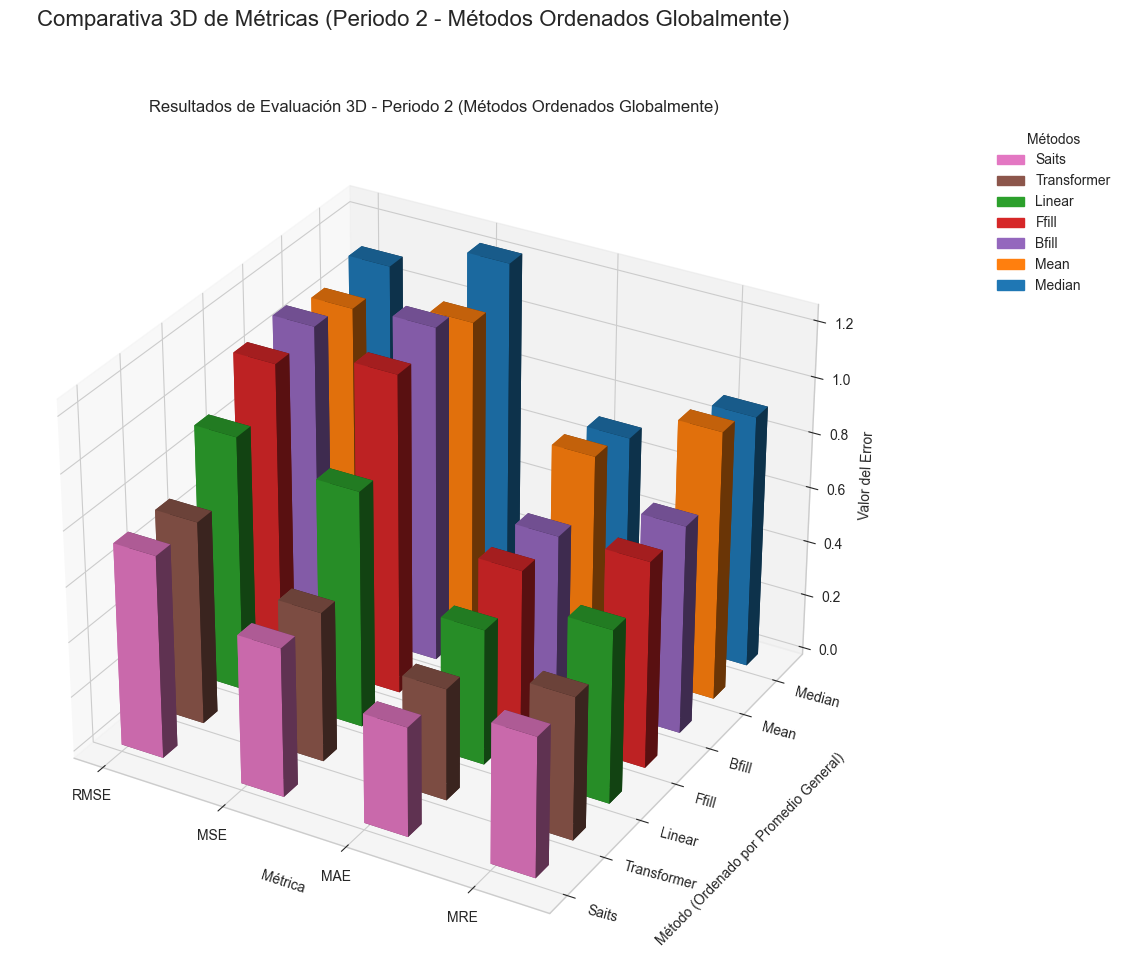

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd

# Datos de la tabla para el Periodo 2
data_periodo2 = {
    'Metrica': ['RMSE', 'MSE', 'MAE', 'MRE'],
    'Median': [1.1103, 1.2329, 0.7177, 0.9161],
    'Mean': [1.0609, 1.1255, 0.7637, 0.9747],
    'Linear': [0.9252, 0.8559, 0.4915, 0.6273],
    'Ffill': [1.0754, 1.1565, 0.5836, 0.7470],
    'Bfill': [1.1018, 1.2140, 0.5894, 0.7544],
    'Transformer': [0.7361, 0.5419, 0.4048, 0.5167],
    'Saits': [0.7345, 0.5395, 0.3962, 0.5057]
}

df_raw_periodo2 = pd.DataFrame(data_periodo2)

# --- Ordenar el DataFrame por el rendimiento promedio de los métodos (por ejemplo) ---
# Primero, necesitamos pivotar la tabla para tener métodos como índice y métricas como columnas
df_pivot = df_raw_periodo2.set_index('Metrica').transpose() # Ahora los métodos son filas

# Calcular el promedio de error para cada método
df_pivot['PromedioError'] = df_pivot.mean(axis=1)

# Ordenar los métodos por este promedio (de menor a mayor error promedio)
df_sorted_methods = df_pivot.sort_values(by='PromedioError', ascending=True)

# Volver a la estructura original (métricas como índice, métodos ordenados como columnas)
# y quitar la columna auxiliar 'PromedioError'
df_periodo2_sorted_for_3d = df_sorted_methods.drop(columns=['PromedioError']).transpose()
# Ahora las columnas de df_periodo2_sorted_for_3d están ordenadas por el rendimiento promedio del método


# Colores para los métodos (usaremos un diccionario para mantener la consistencia)
method_color_map = {
    'Median': '#1f77b4',
    'Mean': '#ff7f0e',
    'Linear': '#2ca02c',
    'Ffill': '#d62728',
    'Bfill': '#9467bd',
    'Transformer': '#8c564b',
    'Saits': '#e377c2'
}


# --- Función para crear el gráfico de barras 3D (modificada para usar el df ordenado) ---
def plot_3d_metrics_comparison_globally_sorted(df_input, title, ax, color_map_dict):
    # El DataFrame df_input ya tiene las columnas (métodos) en el orden deseado
    metrics = df_input.index.tolist() # Métricas ahora son el índice
    methods_sorted = df_input.columns.tolist() # Métodos (columnas) ya están ordenados

    n_metrics = len(metrics)
    n_methods = len(methods_sorted)

    x_pos = np.arange(n_metrics) # Posiciones para las métricas en el eje X
    y_pos = np.arange(n_methods) # Posiciones para los métodos ordenados en el eje Y

    x_mesh, y_mesh = np.meshgrid(x_pos, y_pos)
    x_mesh = x_mesh.flatten()
    y_mesh = y_mesh.flatten()

    z_values = []
    bar_colors = []

    # Iterar en el orden de los métodos ya clasificados en el DataFrame
    for method_idx, method_name in enumerate(methods_sorted):
        for metric_idx, metric_name in enumerate(metrics):
            value = df_input.loc[metric_name, method_name]
            z_values.append(value)
            bar_colors.append(color_map_dict[method_name]) # Usar el color mapeado

    z_values = np.array(z_values)
    dx = dy = 0.35
    dz = z_values

    ax.bar3d(x_mesh, y_mesh, np.zeros_like(dz), dx, dy, dz, color=bar_colors, shade=True)

    ax.set_title(title)
    ax.set_xlabel('Métrica')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(metrics)

    ax.set_ylabel('Método (Ordenado por Promedio General)', labelpad=25)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(methods_sorted, va='center', ha='left', rotation=-15)

    ax.set_zlabel('Valor del Error')

    # Leyenda (ya que los métodos están en un orden fijo ahora)
    handles = [plt.Rectangle((0,0),1,1, color=color_map_dict[method]) for method in methods_sorted]
    ax.legend(handles, methods_sorted, title='Métodos', bbox_to_anchor=(1.15, 1), loc='upper left')


# --- Crear la figura 3D ---
fig = plt.figure(figsize=(16, 11)) # Ajustado el tamaño
plt.style.use('seaborn-v0_8-whitegrid')

ax1 = fig.add_subplot(111, projection='3d')
plot_3d_metrics_comparison_globally_sorted(
    df_periodo2_sorted_for_3d, # Usamos el DataFrame con métodos ordenados
    'Resultados de Evaluación 3D - Periodo 2 (Métodos Ordenados Globalmente)',
    ax1,
    method_color_map
)

plt.tight_layout(rect=[0, 0, 0.83, 0.95]) # Ajustado el rect
plt.suptitle('Comparativa 3D de Métricas (Periodo 2 - Métodos Ordenados Globalmente)', fontsize=16, y=0.98)
plt.show()